[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/07_revision_robustness_analyses.ipynb)

# SAVE-LEWS — robustness analyses added in revision

Three analyses requested in the pre-submission review (Table 3 of the revised manuscript, "robustness (added in revision)"):

| Analysis | Script | Stored output | Re-run time (2-core CPU) |
|---|---|---|---|
| Assimilation ablation: re-evaluate M0/M2/M3 with nudging width 0.02 / 0.08 / 0.16 m and open loop | `thailand/run_revision.py nudgeeval` | `thailand/res_rev_nudgeeval.json` | ~20 min |
| Assimilation ablation: retrain M0 with no assimilation | `thailand/run_revision.py noassim FOLD` | `thailand/res_rev_noassim_f*.json` | ~25 min per fold |
| Fast-store bound sensitivity: retrain M3 with φ_f ≤ B | `thailand/run_revision.py boundB FOLD` (e.g. `bound0.1 3`) | `thailand/res_rev_bound*_f*.json` | ~25 min per fold |
| Jacobian identifiability, Thailand | `thailand/jacobian_thai.py` | `thailand/res_rev_jacobian_thai.json` | ~30 min |
| Jacobian identifiability, Puerto Rico | `puerto_rico/jacobian_pr.py 40` | `puerto_rico/out/rev_jacobian_pr.json` | ~5 min |

By default the notebook summarises the stored outputs (`thailand/summarize_revision.py`). Set the flags to recompute.

In [1]:
import os, sys, subprocess
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, '.'))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', os.path.join(ROOT, 'requirements.txt')], check=True)
print('repository:', ROOT)
RERUN_ASSIM_EVAL = False
RERUN_NOASSIM = False        # 6 folds x ~25 min
RERUN_BOUNDS = False         # 2 bounds x 6 folds x ~25 min
RERUN_JACOBIAN = False
import json, pandas as pd
pd.set_option('display.width', 220)
def sh(script, *args, cwd='thailand'):
    print('>>', cwd, script, *args); subprocess.run([sys.executable, script, *args], cwd=cwd, check=True)
FOLDS = ['0', '1', '3', '4', '5', '6']      # storm 2 (near-saturated) is excluded from all Thai skill comparisons

repository: /content/SAVE-LEWS


In [2]:
if RERUN_ASSIM_EVAL: sh('run_revision.py', 'nudgeeval')
if RERUN_NOASSIM:
    for f in FOLDS: sh('run_revision.py', 'noassim', f)
if RERUN_BOUNDS:
    for b in ['bound0.01', 'bound0.1']:
        for f in FOLDS: sh('run_revision.py', b, f)
if RERUN_JACOBIAN:
    sh('jacobian_thai.py'); sh('jacobian_pr.py', '40', cwd='puerto_rico')
sh('summarize_revision.py')
S = json.load(open('thailand/res_rev_summary.json'))

>> thailand summarize_revision.py


nudge L=0.08|M0|oracle [0.038, 0.092, 0.153]
nudge L=0.08|M0|past [0.024, 0.046, 0.082]
nudge L=0.08|M2|oracle [0.514, 0.576, 0.518]
nudge L=0.08|M2|past [-0.067, -0.107, -0.235]
nudge L=0.08|M3|oracle [0.17, 0.27, 0.331]
nudge L=0.08|M3|past [0.022, 0.048, 0.097]
nudge L=0.02|M0|oracle [0.045, 0.109, 0.185]
nudge L=0.02|M0|past [0.031, 0.061, 0.11]
nudge L=0.02|M2|oracle [0.512, 0.573, 0.512]
nudge L=0.02|M2|past [-0.065, -0.103, -0.225]
nudge L=0.02|M3|oracle [0.178, 0.284, 0.354]
nudge L=0.02|M3|past [0.031, 0.066, 0.13]
nudge L=0.16|M0|oracle [0.035, 0.085, 0.138]
nudge L=0.16|M0|past [0.02, 0.039, 0.068]
nudge L=0.16|M2|oracle [0.515, 0.578, 0.524]
nudge L=0.16|M2|past [-0.066, -0.106, -0.23]
nudge L=0.16|M3|oracle [0.164, 0.258, 0.31]
nudge L=0.16|M3|past [0.017, 0.038, 0.075]
open loop|M0|oracle [0.006, 0.037, 0.07]
open loop|M0|past [0.005, 0.009, 0.015]
open loop|M2|oracle [0.429, 0.526, 0.592]
open loop|M2|past [-0.013, -0.008, 0.005]
open loop|M3|oracle [0.145, 0.23, 0.264]


## 1. Assimilation ablation (Table S5): pooled storm-time skill at 30/60/120 min, six regular held-out storms

In [3]:
A = S['assimilation']
rows = [dict(variant=k.split('|')[0], model=k.split('|')[1], mode=k.split('|')[2], **dict(zip(['30 min', '60 min', '120 min'], v)))
        for k, v in A.items() if k.count('|') == 2]
pd.DataFrame(rows).pivot_table(index=['variant', 'model'], columns='mode', values='60 min')

mode                       oracle   past
variant             model               
nudge L=0.02        M0      0.109  0.061
                    M2      0.573 -0.103
                    M3      0.284  0.066
nudge L=0.08        M0      0.092  0.046
                    M2      0.576 -0.107
                    M3      0.270  0.048
nudge L=0.16        M0      0.085  0.039
                    M2      0.578 -0.106
                    M3      0.258  0.038
open loop           M0      0.037  0.009
                    M2      0.526 -0.008
                    M3      0.230  0.016
retrained open loop M0      0.024  0.014

## 2. Fast-store bound sensitivity (Table S4)

In [4]:
pd.DataFrame(S['bounds']).T

,folds,n_folds,oracle,past,s_matrix_median,fast_part_max_median,wet_without_rain,phi_f_fitted
0.01,"[0, 1, 3, 4, 5, 6]",6,"[0.065, 0.109, 0.159]","[0.024, 0.045, 0.084]",0.0071,0.0,0.462,"[0.0091, 0.0057, 0.0053, 0.0053, 0.0057, 0.0055]"
0.05,"[0, 1, 3, 4, 5, 6]",6,"[0.17, 0.27, 0.331]","[0.022, 0.048, 0.097]",0.0098,0.014,0.466,"[0.0408, 0.028, 0.0279, 0.0279, 0.0291, 0.0311]"
0.1,"[0, 1, 3, 4, 5, 6]",6,"[0.198, 0.309, 0.352]","[0.016, 0.039, 0.079]",0.0104,0.013,0.455,"[0.0538, 0.0282, 0.0275, 0.0275, 0.0352, 0.0262]"
M2 (unbounded),"[0, 1, 3, 4, 5, 6]",6,"[0.514, 0.576, 0.518]","[-0.067, -0.107, -0.235]",0.0109,0.044,0.019,NaN


## 3. Jacobian identifiability (Fig. 11, Table S8)

In [5]:
pd.DataFrame({k: {c: v[c] for c in ['resid_rmse', 'practical_rank', 'n_params', 'condition', 'matrix_rank', 'matrix_condition', 'input_sensitivity_rms'] if c in v}
              for k, v in S['jacobian'].items()}).T

,resid_rmse,practical_rank,n_params,condition,matrix_rank,matrix_condition,input_sensitivity_rms
Thailand 30 cm,0.033981,0.0,8.0,652.923525,0.0,13.182635,NaN
Utuado 72 cm,0.055503,2.0,5.0,602.630246,1.0,451.848080,0.874725
Utuado 57 cm,0.038006,1.0,5.0,383.155012,1.0,371.913898,0.888915
Toro Negro 90 cm,0.036189,1.0,5.0,2.564369,0.0,1.291365,0.000000
Toro Negro 110 cm,0.010554,4.0,5.0,5.058639,2.0,1.270021,0.000000


ok


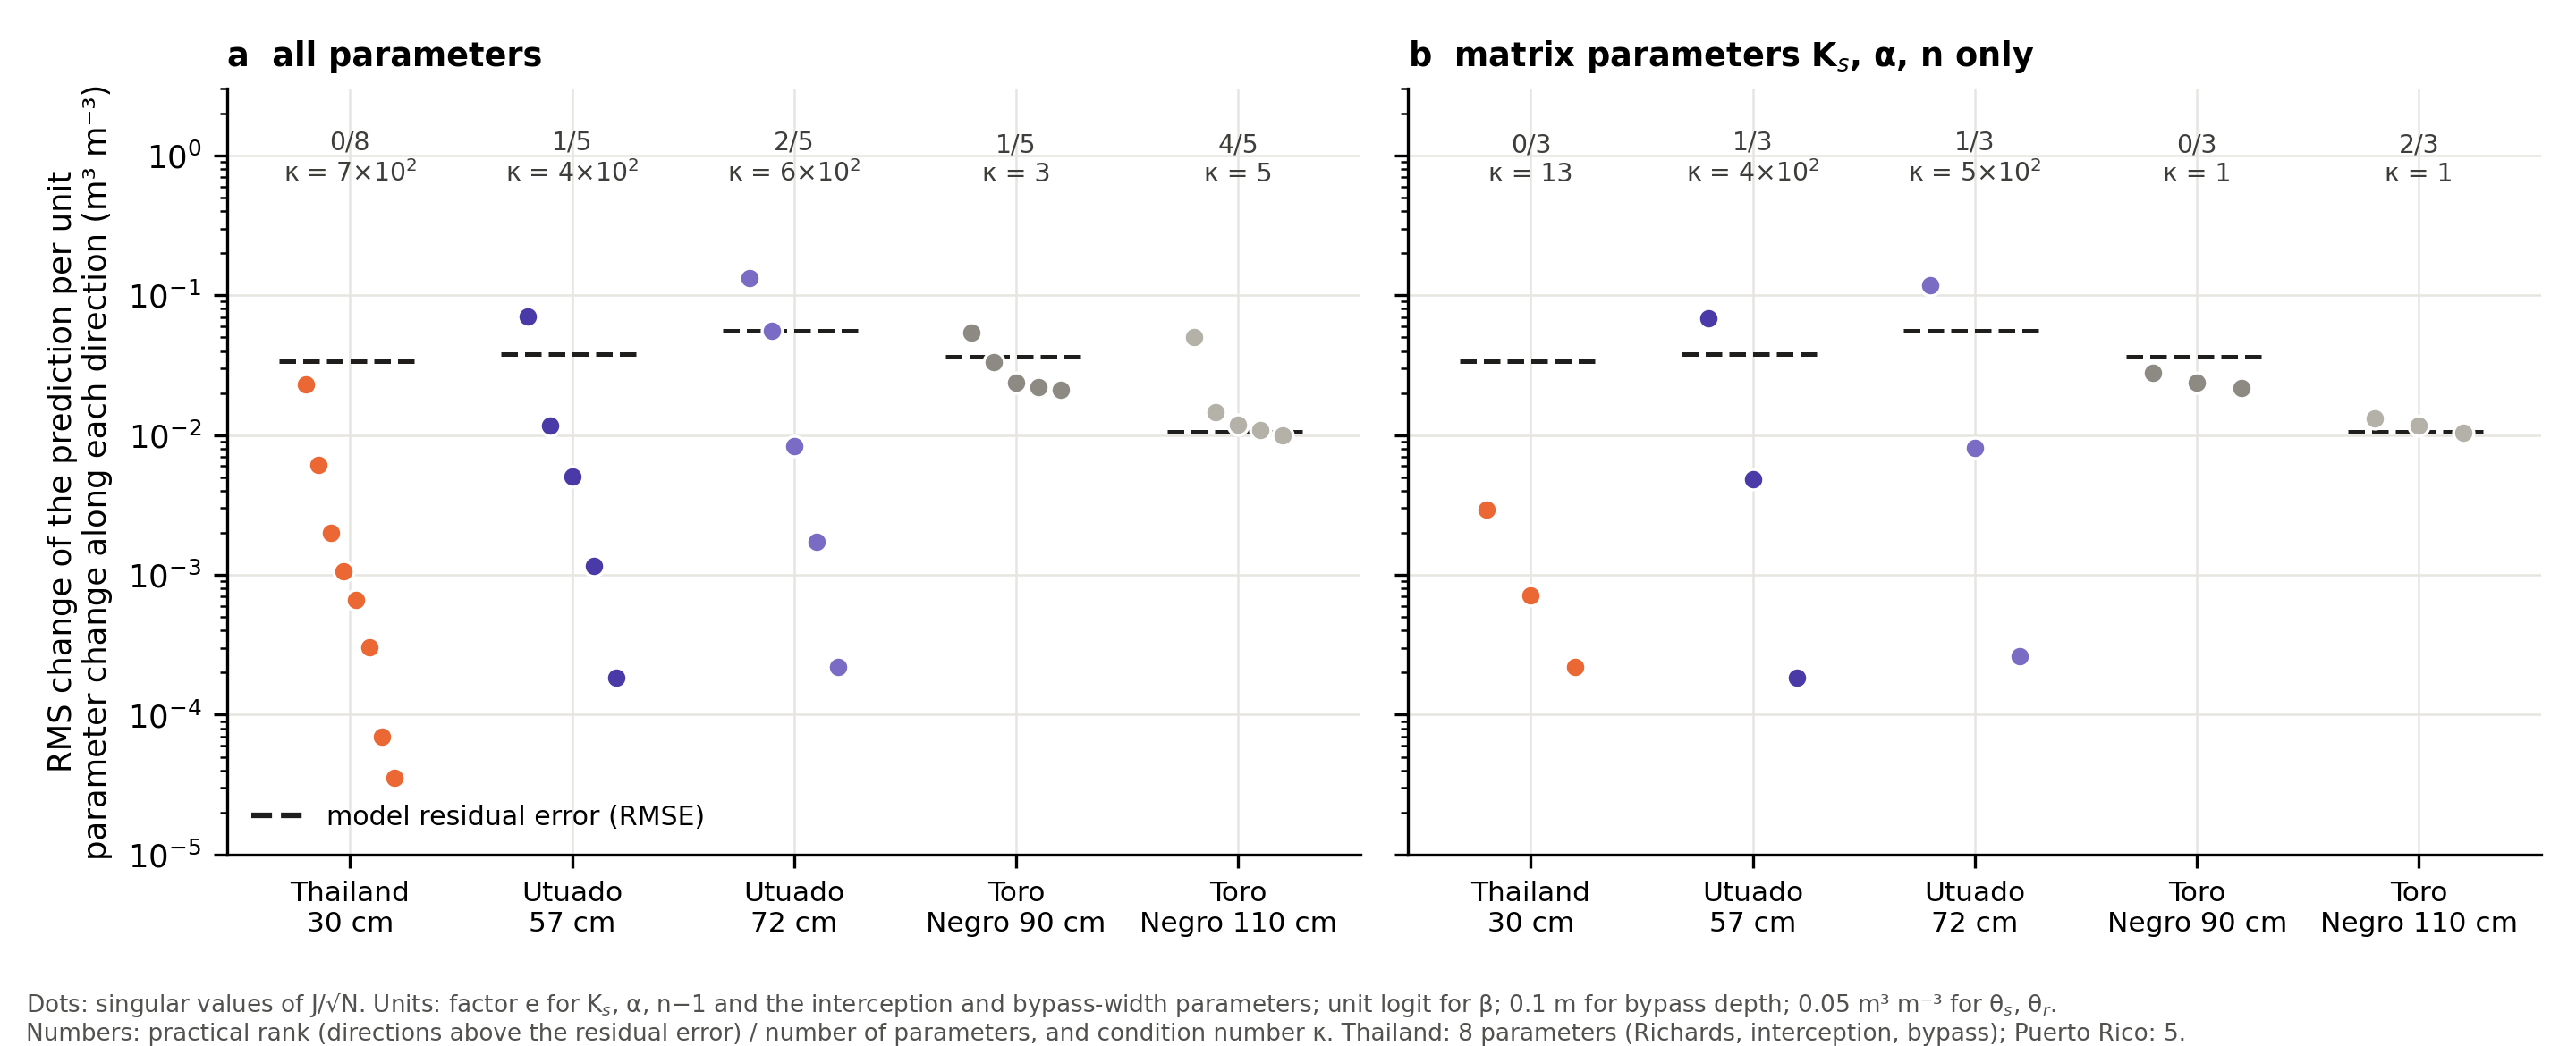

In [6]:
subprocess.run([sys.executable, 'figures/fig_jacobian.py'], check=True)
from IPython.display import Image; Image('figures/parts/Fig11_jacobian.png', width=900)